# Cell 1: Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
import os

os.makedirs('figures', exist_ok=True)

# Cell 2: Load feature matrix

In [2]:
data = np.load('data/feature_matrix.npz', allow_pickle=True)
X = data['X']
y = data['y']
feature_names = list(data['feature_names'])

print(f"Feature matrix shape: {X.shape}")
print(f"Label distribution: {Counter(y)}")
print(f"Features: {feature_names}")

Feature matrix shape: (9561, 8)
Label distribution: Counter({'N': 4665, 'L': 2491, 'R': 1825, 'V': 547, 'A': 33})
Features: ['RR_interval_ms', 'RR_ratio', 'R_amplitude', 'QRS_duration_ms', 'P_wave_amplitude', 'T_wave_amplitude', 'beat_mean', 'beat_std']


# Cell 3: Train/test split (stratified)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} beats")
print(f"Test set:  {X_test.shape[0]} beats")
print(f"Train class distribution: {Counter(y_train)}")
print(f"Test class distribution:  {Counter(y_test)}")

Train set: 7648 beats
Test set:  1913 beats
Train class distribution: Counter({'N': 3732, 'L': 1993, 'R': 1460, 'V': 437, 'A': 26})
Test class distribution:  Counter({'N': 933, 'L': 498, 'R': 365, 'V': 110, 'A': 7})


# Cell 4: Train Random Forest

In [4]:
clf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)
print("Training complete.")
print(f"Number of trees: {clf.n_estimators}")

Training complete.
Number of trees: 200


# Cell 5: Evaluate on test set

In [5]:
y_pred = clf.predict(X_test)

print("Per-class F1 scores:")
print(classification_report(y_test, y_pred, digits=3))

Per-class F1 scores:
              precision    recall  f1-score   support

           A      1.000     0.857     0.923         7
           L      0.998     1.000     0.999       498
           N      1.000     0.996     0.998       933
           R      0.986     1.000     0.993       365
           V      0.991     0.982     0.986       110

    accuracy                          0.996      1913
   macro avg      0.995     0.967     0.980      1913
weighted avg      0.996     0.996     0.996      1913



# Cell 6: Plot confusion matrix

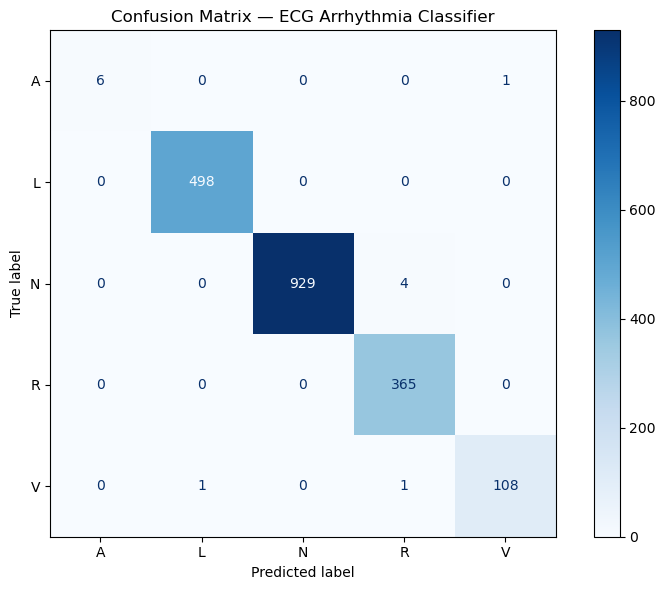

Saved: figures/confusion_matrix.png


In [6]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — ECG Arrhythmia Classifier')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150)
plt.show()
print("Saved: figures/confusion_matrix.png")

# Cell 7: Plot feature importances

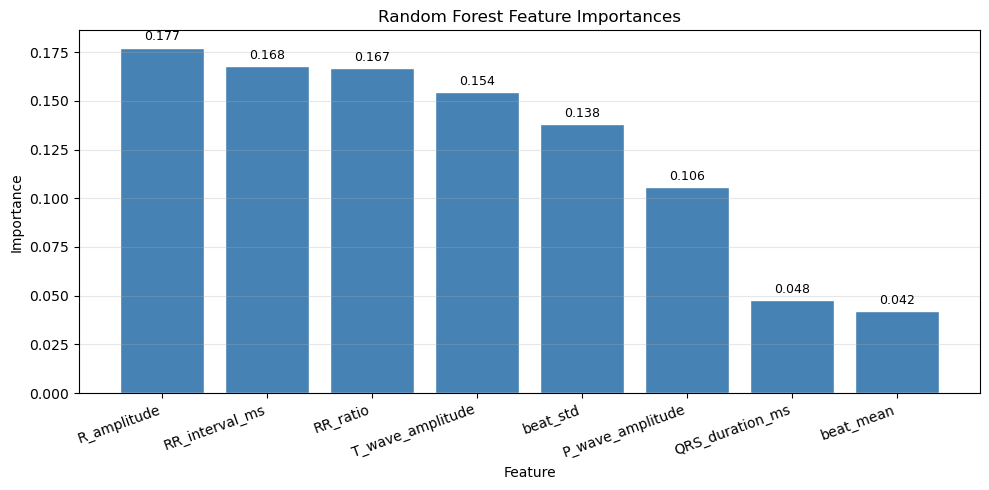

Saved: figures/feature_importances.png


In [7]:
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(sorted_features, sorted_importances, color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.set_title('Random Forest Feature Importances')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('figures/feature_importances.png', dpi=150)
plt.show()
print("Saved: figures/feature_importances.png")

# Cell 8: Per-class F1 summary table

In [8]:
classes = clf.classes_
f1_scores = f1_score(y_test, y_pred, average=None, labels=classes)
test_counts = [Counter(y_test)[c] for c in classes]
train_counts = [Counter(y_train)[c] for c in classes]

print(f"{'Class':<8} {'Train':>8} {'Test':>8} {'F1':>8}")
print("-" * 36)
for cls, tr, te, f1 in zip(classes, train_counts, test_counts, f1_scores):
    print(f"{cls:<8} {tr:>8} {te:>8} {f1:>8.3f}")

overall_f1 = f1_score(y_test, y_pred, average='weighted')
print(f"\nWeighted F1: {overall_f1:.3f}")

Class       Train     Test       F1
------------------------------------
A              26        7    0.923
L            1993      498    0.999
N            3732      933    0.998
R            1460      365    0.993
V             437      110    0.986

Weighted F1: 0.996


# Cell 9: Save model summary

In [9]:
summary = {
    'n_train': X_train.shape[0],
    'n_test': X_test.shape[0],
    'n_features': X.shape[1],
    'classes': list(classes),
    'weighted_f1': float(overall_f1),
    'per_class_f1': dict(zip(classes, f1_scores.tolist()))
}

import json
with open('data/model_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("Saved: data/model_summary.json")
print(json.dumps(summary, indent=2))

Saved: data/model_summary.json
{
  "n_train": 7648,
  "n_test": 1913,
  "n_features": 8,
  "classes": [
    "A",
    "L",
    "N",
    "R",
    "V"
  ],
  "weighted_f1": 0.9963240465228856,
  "per_class_f1": {
    "A": 0.9230769230769231,
    "L": 0.9989969909729187,
    "N": 0.9978517722878625,
    "R": 0.9931972789115646,
    "V": 0.9863013698630136
  }
}
